<p style="text-align: center; font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;">
LoRaWAN Indoor Dataset: Kalman Filtering
</p>

This notebook applies a self-tuning 1D Kalman filter to the time-ordered RSSI series for each device. It reads the train/test splits created in `01_Data Preparation.ipynb`, computes `filtered_rssi` and `exp_pl_filtered`, and saves the filtered outputs for downstream notebooks:
- `03_Path_Loss_Modeling.ipynb`
- `04_Distance_Estimation.ipynb`

### Kalman Filtering


In [1]:
import os
import time
import platform
import socket
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

sns.set_style("darkgrid")
sns.set_context("talk", font_scale=0.9)

In [2]:
INPUT_TRAIN = 'Data Files/train.csv'
INPUT_TEST = 'Data Files/test.csv'
OUTPUT_TRAIN = 'Data Files/train_kf.csv'
OUTPUT_TEST = 'Data Files/test_kf.csv'

required_cols = {
    'device_id', 'time', 'rssi', 'exp_pl',
    'distance', 'frequency', 'c_walls', 'w_walls',
    'co2', 'humidity', 'pm25', 'pressure', 'temperature', 'snr'
}

train_df = pd.read_csv(INPUT_TRAIN, parse_dates=['time'])
test_df = pd.read_csv(INPUT_TEST, parse_dates=['time'])

missing_train = required_cols - set(train_df.columns)
missing_test = required_cols - set(test_df.columns)

if missing_train or missing_test:
    raise ValueError(
        f"Missing columns. train: {missing_train}, test: {missing_test}. "
        "Rerun 01_Data Preparation.ipynb."
    )

train_df = train_df.sort_values('time').reset_index(drop=True)
test_df = test_df.sort_values('time').reset_index(drop=True)

print("Loaded time-ordered splits from 01_Data Preparation.ipynb")
print(f"train_df shape: {train_df.shape}")
print(f"test_df shape: {test_df.shape}")
print(f"Train window: {train_df['time'].min()} -> {train_df['time'].max()}")
print(f"Test  window: {test_df['time'].min()} -> {test_df['time'].max()}")

display(train_df.head())
display(test_df.head())

Loaded time-ordered splits from 01_Data Preparation.ipynb
train_df shape: (1663627, 14)
test_df shape: (415907, 14)
Train window: 2024-10-01 00:01:07.420593+00:00 -> 2025-08-12 17:18:53.293125+00:00
Test  window: 2025-08-12 17:19:02.126782+00:00 -> 2025-09-30 23:59:55.971870+00:00


,device_id,rssi,distance,frequency,c_walls,w_walls,co2,humidity,pm25,pressure,temperature,snr,exp_pl,time
0,ED5,-102.0,40,868.1,2,2,440.0,45.46,0.46,313.80,22.41,10.2,119.26,2024-10-01 00:01:07.420593+00:00
1,ED2,-66.0,23,867.9,0,2,451.0,40.59,0.43,314.81,22.83,11.0,83.26,2024-10-01 00:01:25.764905+00:00
2,ED4,-119.0,37,867.1,0,5,435.0,37.33,0.05,315.54,24.06,-1.8,136.26,2024-10-01 00:01:50.313519+00:00
3,ED5,-100.0,40,867.7,2,2,449.0,45.43,0.40,313.84,22.41,10.8,117.26,2024-10-01 00:02:07.467816+00:00
4,ED2,-64.0,23,867.7,0,2,451.0,40.57,0.21,314.80,22.84,8.8,81.26,2024-10-01 00:02:25.817808+00:00


,device_id,rssi,distance,frequency,c_walls,w_walls,co2,humidity,pm25,pressure,temperature,snr,exp_pl,time
0,ED4,-84.0,37,868.5,0,5,454.0,36.31,2.50,321.97,29.12,9.2,101.26,2025-08-12 17:19:02.126782+00:00
1,ED0,-51.0,10,867.7,0,0,411.0,35.23,10.15,319.99,29.33,12.0,68.26,2025-08-12 17:19:19.243640+00:00
2,ED3,-69.0,18,868.1,1,2,430.0,24.39,6.00,320.50,42.69,12.0,86.26,2025-08-12 17:19:21.750967+00:00
3,ED1,-54.0,8,867.5,1,0,424.0,35.60,6.02,320.96,29.76,9.0,71.26,2025-08-12 17:19:44.308397+00:00
4,ED5,-94.0,40,867.9,2,2,440.0,40.62,8.27,320.54,27.01,12.0,111.26,2025-08-12 17:19:49.123572+00:00


In [3]:
#  Self‑tuning 1D Kalman filter for RSSI 
def adaptive_kf_rssi(z,
                     Q_init=0.003,       #  drift control (~0.055 dB)
                     R_init=0.22,        # leaner measurement noise (~0.47 dB std)
                     gamma_min=0.95,     # allow R to shrink by 5%
                     gamma_max=1.05,     # allow it to inflate by 5% at most
                     forget_factor=0.99, # smooth adaptation over ~100 samples
                     R_guard=(0.12,0.38),# clamp R to [0.12,0.38] for stability
                     adapt_Q=False,      # keep Q fixed unless severe model mismatch
                     Q_bounds=(1e-5,2e-2)):
    """
    Innovation‑based adaptive 1D Kalman filter for RSSI.
    Design rationale:
      - Q_init=0.003 dB²: ultra-slow drift tracking
      - R_init=0.22 dB²: matches tighter RSSI scatter
      - gamma ∈ [0.95,1.05]: minimal adaptation for fine smoothing
      - forget_factor=0.99: very long memory to cut jitter
      - R_guard: keeps R within reasonable bounds even after extreme α values
      - adapt_Q=False: Q is well‑matched; enabling Q adaptation can conflate
        process vs. measurement noise unless model errors are large
    """
    n = len(z)
    x_hat = np.zeros(n)    # filtered RSSI
    P_hat = np.zeros(n)    # estimate covariance

    # initialize state and covariances
    x_hat[0] = z[0]
    P_hat[0] = R_init
    Q, R = Q_init, R_init

    for k in range(1, n):
        # — Prediction step (random‑walk model) —
        x_pred = x_hat[k-1]
        P_pred = P_hat[k-1] + Q

        # — Measurement update —
        innov  = z[k] - x_pred
        S      = P_pred + R
        K_gain = P_pred / S
        x_hat[k] = x_pred + K_gain * innov
        P_hat[k] = (1 - K_gain) * P_pred

        # — Innovation‑based adaptation of R —
        alpha = innov**2 / S
        alpha = np.clip(alpha, gamma_min, gamma_max)
        R_new = forget_factor * R + (1 - forget_factor) * (alpha * R)
        R = np.clip(R_new, R_guard[0], R_guard[1])

        if adapt_Q:
            Q_new = forget_factor * Q + (1 - forget_factor) * (alpha * Q)
            Q = float(np.clip(Q_new, Q_bounds[0], Q_bounds[1]))

    return x_hat

# Apply to train & test DataFrames per device
def apply_self_tuning(df):
    """
    Groups by 'device_id' and applies adaptive_kf_rssi to each RSSI series.
    """
    return df.groupby('device_id')['rssi'] \
             .transform(lambda arr: adaptive_kf_rssi(
                 arr.values,
                 Q_init=0.003, R_init=0.22,
                 gamma_min=0.95, gamma_max=1.05,
                 forget_factor=0.99,
                 R_guard=(0.12, 0.38),
                 adapt_Q=False
             ))

# Load your DataFrames (train_df, test_df) with 'device_id' & 'rssi'
train_df['filtered_rssi'] = apply_self_tuning(train_df)
test_df ['filtered_rssi'] = apply_self_tuning(test_df)

# Compute expected path‑loss from system constants
TX_P  = 14    # dBm
TX_CL = 0.14  # dB cable loss
TX_AG = 0.4   # dBi transmit antenna gain
RX_AG = 3     # dBi receive antenna gain

offset = TX_P - TX_CL + TX_AG + RX_AG  # 17.26 dB reference

train_df['exp_pl_filtered'] = offset - train_df['filtered_rssi']
test_df ['exp_pl_filtered'] = offset - test_df['filtered_rssi']

display(
    train_df[['device_id', 'time', 'rssi', 'filtered_rssi', 'exp_pl', 'exp_pl_filtered']].head()
)
display(
    test_df[['device_id', 'time', 'rssi', 'filtered_rssi', 'exp_pl', 'exp_pl_filtered']].head()
)

,device_id,time,rssi,filtered_rssi,exp_pl,exp_pl_filtered
0,ED5,2024-10-01 00:01:07.420593+00:00,-102.0,-102.000000,119.26,119.260000
1,ED2,2024-10-01 00:01:25.764905+00:00,-66.0,-66.000000,83.26,83.260000
2,ED4,2024-10-01 00:01:50.313519+00:00,-119.0,-119.000000,136.26,136.260000
3,ED5,2024-10-01 00:02:07.467816+00:00,-100.0,-100.993228,117.26,118.253228
4,ED2,2024-10-01 00:02:25.817808+00:00,-64.0,-64.993228,81.26,82.253228


,device_id,time,rssi,filtered_rssi,exp_pl,exp_pl_filtered
0,ED4,2025-08-12 17:19:02.126782+00:00,-84.0,-84.0,101.26,101.26
1,ED0,2025-08-12 17:19:19.243640+00:00,-51.0,-51.0,68.26,68.26
2,ED3,2025-08-12 17:19:21.750967+00:00,-69.0,-69.0,86.26,86.26
3,ED1,2025-08-12 17:19:44.308397+00:00,-54.0,-54.0,71.26,71.26
4,ED5,2025-08-12 17:19:49.123572+00:00,-94.0,-94.0,111.26,111.26


In [4]:
cols_out = [
    'device_id', 'time',
    'rssi', 'filtered_rssi',
    'exp_pl', 'exp_pl_filtered',
    'distance', 'frequency', 'c_walls', 'w_walls',
    'co2', 'humidity', 'pm25', 'pressure', 'temperature', 'snr'
]

os.makedirs('Data Files', exist_ok=True)

train_df[cols_out].to_csv(OUTPUT_TRAIN, index=False)
test_df[cols_out].to_csv(OUTPUT_TEST, index=False)

print(f"Saved {OUTPUT_TRAIN}")
print(f"Saved {OUTPUT_TEST}")
print("Exported columns:", cols_out)

Saved Data Files/train_kf.csv
Saved Data Files/test_kf.csv
Exported columns: ['device_id', 'time', 'rssi', 'filtered_rssi', 'exp_pl', 'exp_pl_filtered', 'distance', 'frequency', 'c_walls', 'w_walls', 'co2', 'humidity', 'pm25', 'pressure', 'temperature', 'snr']


### Kalman Filter Results

In [5]:
# Calculate the standard deviation of raw RSSI per device
raw_std = train_df.groupby('device_id')['rssi'].std()

# Calculate the standard deviation of filtered RSSI per device
filtered_std = train_df.groupby('device_id')['filtered_rssi'].std()

# Combine the results into a DataFrame
results_df = pd.DataFrame({
    'Raw_Std (dB)': raw_std,
    'Filtered_Std (dB)': filtered_std
})

# Compute the percentage reduction in standard deviation per device
results_df['Reduction_Percentage (%)'] = ((results_df['Raw_Std (dB)'] - results_df['Filtered_Std (dB)']) /
                                            results_df['Raw_Std (dB)']) * 100

# Display the DataFrame with the results
print("\nReduction in RSSI standard deviation per device:\n")
display(results_df)

# Calculate overall averages
average_raw_std = results_df['Raw_Std (dB)'].mean()
average_filtered_std = results_df['Filtered_Std (dB)'].mean()
average_reduction = results_df['Reduction_Percentage (%)'].mean()

# Display the summary
print("\nSummary:")
print("Average Raw RSSI Std Dev: {:.2f} dB".format(average_raw_std))
print("Average Filtered RSSI Std Dev: {:.2f} dB".format(average_filtered_std))
print("Overall Average Reduction: {:.2f}%".format(average_reduction))


Reduction in RSSI standard deviation per device:



,Raw_Std (dB),Filtered_Std (dB),Reduction_Percentage (%)
device_id,,,
ED0,13.753228,6.409404,53.397090
ED1,14.084133,7.240417,48.591670
ED2,8.807720,5.641543,35.947745
ED3,12.009516,5.629229,53.126932
ED4,6.832330,3.794548,44.461868
ED5,4.941464,4.284519,13.294531



Summary:
Average Raw RSSI Std Dev: 10.07 dB
Average Filtered RSSI Std Dev: 5.50 dB
Overall Average Reduction: 41.47%


In [6]:
# Runtime benchmark for the existing forward-only KF pipeline

#  machine / CPU info 
def get_cpu_info():
    info = {
        "hostname": socket.gethostname(),
        "platform": platform.platform(),
        "python_version": platform.python_version(),
        "processor": platform.processor(),
        "logical_cores": os.cpu_count(),
    }

    # Linux fallback for richer CPU name
    cpu_name = None
    if Path("/proc/cpuinfo").exists():
        try:
            with open("/proc/cpuinfo", "r", encoding="utf-8", errors="ignore") as f:
                for line in f:
                    if "model name" in line:
                        cpu_name = line.split(":", 1)[1].strip()
                        break
        except Exception:
            pass

    info["cpu_name"] = cpu_name if cpu_name else info["processor"]
    return info

machine_info = get_cpu_info()

print("Machine info:")
for k, v in machine_info.items():
    print(f"  {k}: {v}")


#  benchmark the CURRENT implementation exactly as used 
def benchmark_existing_kf_pipeline(df, repeats=10):
    """
    Times the current evaluation-stage smoothing pipeline exactly as implemented:
      apply_self_tuning(df) + path-loss formation from filtered RSSI.
    Reports total time and average microseconds per packet.
    """
    times = []
    n_packets = len(df)

    # warm-up
    filtered = apply_self_tuning(df)
    _ = offset - filtered

    for _ in range(repeats):
        t0 = time.perf_counter()
        filtered = apply_self_tuning(df)
        exp_pl_filtered = offset - filtered
        t1 = time.perf_counter()
        times.append(t1 - t0)

    mean_s = float(np.mean(times))
    std_s = float(np.std(times, ddof=1)) if len(times) > 1 else 0.0
    mean_us_per_packet = mean_s / n_packets * 1e6
    std_us_per_packet = std_s / n_packets * 1e6

    out = {
        "repeats": repeats,
        "n_packets": n_packets,
        "mean_total_s": mean_s,
        "std_total_s": std_s,
        "mean_us_per_packet": mean_us_per_packet,
        "std_us_per_packet": std_us_per_packet,
    }
    return out

bench = benchmark_existing_kf_pipeline(test_df, repeats=10)

print("\nBenchmark results (existing KF + path-loss formation):")
for k, v in bench.items():
    print(f"  {k}: {v}")

Machine info:
  hostname: ubi45
  platform: Linux-6.17.0-14-generic-x86_64-with-glibc2.39
  python_version: 3.12.3
  processor: x86_64
  logical_cores: 32
  cpu_name: AMD Ryzen 9 7950X 16-Core Processor

Benchmark results (existing KF + path-loss formation):
  repeats: 10
  n_packets: 415907
  mean_total_s: 1.6244272645562887
  std_total_s: 0.005591282520306108
  mean_us_per_packet: 3.9057463917565434
  std_us_per_packet: 0.013443588399103904


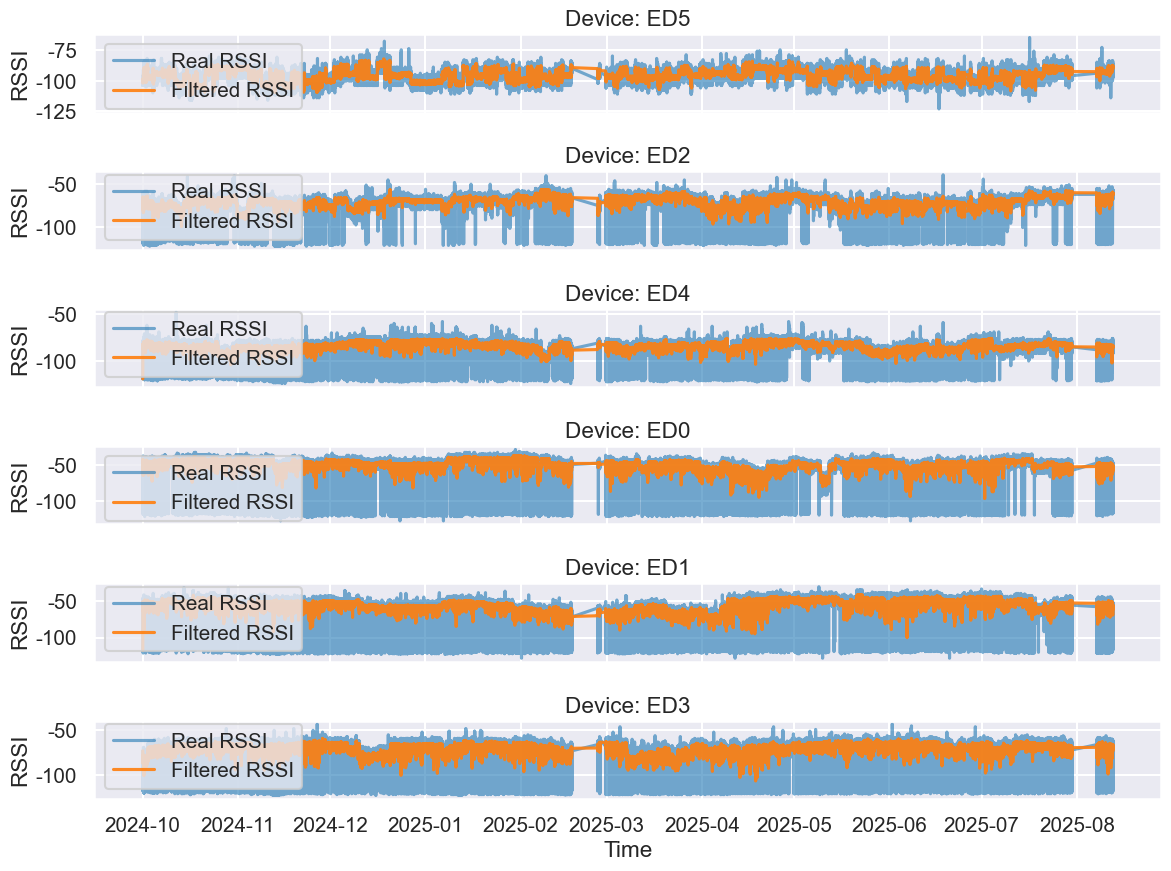

In [7]:
# Plot train data (Real vs. Filtered RSSI) for each device
device_ids = train_df['device_id'].unique()
num_devices = len(device_ids)
fig, axes = plt.subplots(nrows=num_devices, ncols=1, figsize=(12, 1.5*num_devices), sharex=True)
if num_devices == 1:
    axes = [axes]

for ax, device in zip(axes, device_ids):
    device_data = train_df[train_df['device_id'] == device].sort_values('time')
    ax.plot(device_data['time'], device_data['rssi'], label='Real RSSI', alpha=0.6)
    ax.plot(device_data['time'], device_data['filtered_rssi'], label='Filtered RSSI', alpha=0.9)
    ax.set_title(f'Device: {device}')
    ax.set_ylabel('RSSI')
    ax.legend()

plt.xlabel('Time')
plt.tight_layout()
plt.show()

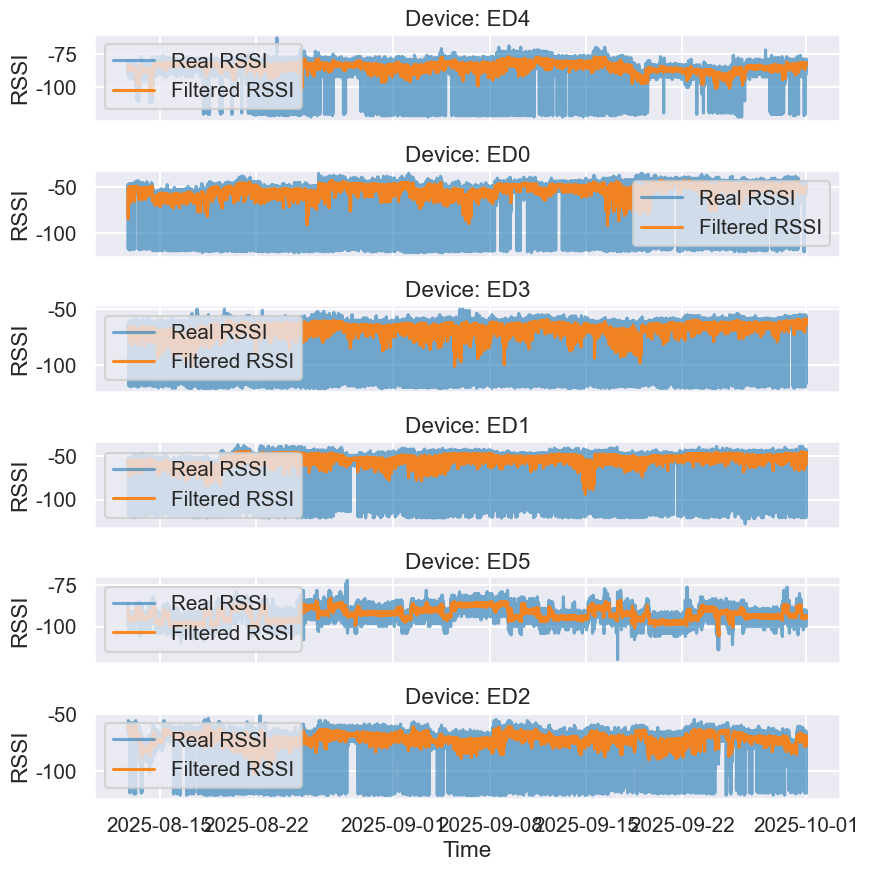

In [8]:
# Plot test data (Real vs. Filtered RSSI) for each device
device_ids_test = test_df['device_id'].unique()
num_devices_test = len(device_ids_test)
fig, axes = plt.subplots(nrows=num_devices_test, ncols=1, figsize=(9, 1.5*num_devices_test), sharex=True)
if num_devices_test == 1:
    axes = [axes]

for ax, device in zip(axes, device_ids_test):
    device_data = test_df[test_df['device_id'] == device].sort_values('time')
    ax.plot(device_data['time'], device_data['rssi'], label='Real RSSI', alpha=0.6)
    ax.plot(device_data['time'], device_data['filtered_rssi'], label='Filtered RSSI', alpha=0.9)
    ax.set_title(f'Device: {device}')
    ax.set_ylabel('RSSI')
    ax.legend()

plt.xlabel('Time')
plt.tight_layout()
plt.show()

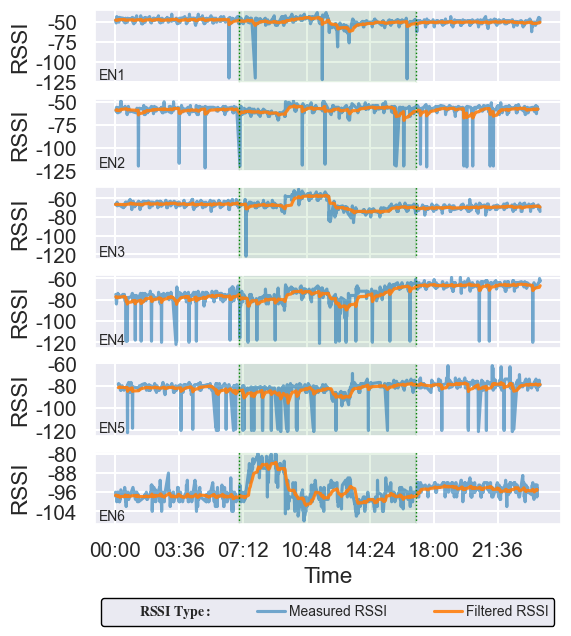

In [9]:
# Ensure 'time' column is in datetime format
train_df['time'] = pd.to_datetime(train_df['time'])

# Define the one-day segment (December 20, 2024)
segment_start = '2024-12-20 00:00:00'
segment_end   = '2024-12-20 23:59:59'
train_df_segment = train_df[
    (train_df['time'] >= segment_start) & 
    (train_df['time'] <= segment_end)
]

# Device mapping: original ID to display name
device_map = {'ED0': 'EN1', 'ED1': 'EN2', 'ED2': 'EN3', 'ED3': 'EN4', 'ED4': 'EN5', 'ED5': 'EN6'}

# Get unique device IDs in ascending order
device_ids = sorted(train_df_segment['device_id'].unique())
num_devices = len(device_ids)

# Create subplots for each device
fig, axes = plt.subplots(nrows=num_devices, ncols=1, figsize=(6, 1 * num_devices), sharex=True)
if num_devices == 1:
    axes = [axes]

# Define the highlight window (7 AM to 5 PM)
highlight_start = pd.to_datetime('2024-12-20 07:00:00')
highlight_end   = pd.to_datetime('2024-12-20 17:00:00')

for ax, device in zip(axes, device_ids):
    device_data = train_df_segment[train_df_segment['device_id'] == device].sort_values('time')
    
    # Plot real vs. filtered RSSI
    ax.plot(device_data['time'], device_data['rssi'], label='Measured RSSI', alpha=0.6)
    ax.plot(device_data['time'], device_data['filtered_rssi'], label='Filtered RSSI', alpha=0.9)
    
    # Highlight 7 AM to 5 PM with a translucent rectangle
    ax.axvspan(highlight_start, highlight_end, color='green', alpha=0.1)
    # Add dotted lines on the left and right edges of the highlight
    ax.axvline(highlight_start, color='green', linestyle=':', linewidth=1)
    ax.axvline(highlight_end,   color='green', linestyle=':', linewidth=1)
    
    # Add device name annotation (bottom left) using our mapping
    device_label = device_map.get(device, device)
    ax.text(
        0.01, 0.01, device_label,
        transform=ax.transAxes, 
        fontsize=10,
        verticalalignment='bottom', 
        horizontalalignment='left'
    )
    
    ax.set_ylabel('RSSI')
    
    # Set the common x-axis to have 10 ticks
    ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
    # Optional: format x-axis labels for datetimes
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
    # Set y-axis tick locator to force 4 ticks for all subplots
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
    
    # Set all subplot borders (spines) to width 2
    for spine in ax.spines.values(): spine.set_linewidth(2)

# Finalize subplot layout and compute positions
plt.tight_layout(h_pad=0.01)  # Reduced gap between plots
fig.canvas.draw()

# Get left & width of the first subplot in figure coords
pos = axes[0].get_position()

# Shared legend below the figure, spanning exactly the subplot width
dummy_handle = mpatches.Patch(color='none', label=r'$\mathbf{RSSI\ Type:}$')
handles, labels = axes[0].get_legend_handles_labels()
handles = [dummy_handle] + handles
labels  = [r'$\mathbf{RSSI\ Type:}$'] + labels

legend = fig.legend(
    handles, labels,
    loc='lower left',
    bbox_to_anchor=(pos.x0, -0.08, pos.width, 0.05),
    mode='expand',
    ncol=3,
    frameon=True,
    fontsize=10,
    labelspacing=0.1,
    columnspacing=0.5,
    handletextpad=0.3
)
legend.get_frame().set_linewidth(1)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_alpha(1)

plt.xlabel('Time')

# Save the figure at high resolution without cropping
#plt.savefig('../all_data_files/Localization/Real_vs_FilteredRSSI_over_shortTime.png', dpi=2000, bbox_inches='tight', pad_inches=0.01)
plt.show()